In [9]:
# Step 1: Install required dependencies
!pip install -q torch torchvision pandas numpy scikit-learn pillow matplotlib joblib

In [10]:
# Step 2: Fetch the benchmark dataset from GitHub
!git clone https://github.com/emanhamed/Houses-dataset.git

fatal: destination path 'Houses-dataset' already exists and is not an empty directory.


In [11]:
# Step 3: Imports & Hardware Check
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device.type.upper()}")
if device.type == "cuda":
    print(f"GPU Details: {torch.cuda.get_device_name(0)}")

Using device: CUDA
GPU Details: Tesla T4


### Step 4: Preprocessing Data Cleaners & PyTorch Dataset Loader

In [12]:
IMG_SIZE = 224

# Pre-trained ImageNet Normalization
IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_clean_tabular_data(info_txt_path: str) -> pd.DataFrame:
    cols = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
    df = pd.read_csv(info_txt_path, sep=" ", header=None, names=cols)
    df["zipcode"] = df["zipcode"].astype(str)
    df["area"] = df["area"].astype(float)
    df["price"] = df["price"].astype(float)
    df["bedrooms"] = df["bedrooms"].astype(float)
    df["bathrooms"] = df["bathrooms"].astype(float)
    return df

class HousingDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_dir: str, scaler: StandardScaler = None, zip_list: list = None, is_training: bool = True):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.is_training = is_training
        self.num_features = ["bedrooms", "bathrooms", "area"]
        
        if scaler is None and is_training:
            self.scaler = StandardScaler()
            self.scaled_num = self.scaler.fit_transform(self.df[self.num_features])
            joblib.dump(self.scaler, "tabular_scaler.joblib")
        elif scaler is not None:
            self.scaler = scaler
            self.scaled_num = self.scaler.transform(self.df[self.num_features])
        else:
            self.scaler = StandardScaler()
            self.scaled_num = self.scaler.fit_transform(self.df[self.num_features])

        # Shared Zipcode vocabulary prevents dynamic dimension mismatches between datasets
        if zip_list is None:
            self.zip_list = sorted(list(self.df["zipcode"].unique()))
            if is_training:
                joblib.dump(self.zip_list, "zip_list.joblib")
        else:
            self.zip_list = zip_list

        self.onehot_zips = pd.get_dummies(self.df["zipcode"]).reindex(columns=self.zip_list, fill_value=0).values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        house_id = self.df.iloc[idx].name + 1
        image_name = f"{house_id}_frontal.jpg"
        image_path = os.path.join(self.image_dir, image_name)
        
        if os.path.exists(image_path):
            image = Image.open(image_path).convert("RGB")
        else:
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(240, 240, 240))
            
        image_tensor = IMAGE_TRANSFORM(image)
        
        num_vec = self.scaled_num[idx].astype(np.float32)
        zip_vec = self.onehot_zips[idx]
        tabular_vec = np.concatenate([num_vec, zip_vec])
        tabular_tensor = torch.tensor(tabular_vec, dtype=torch.float32)
        
        price = self.df.iloc[idx]["price"]
        price_tensor = torch.tensor(price, dtype=torch.float32)
        
        return (image_tensor, tabular_tensor), price_tensor

### Step 5: Late Fusion Multimodal Model Architecture in PyTorch

In [13]:
class MultimodalHousingPriceModel(nn.Module):
    def __init__(self, tabular_input_dim: int):
        super(MultimodalHousingPriceModel, self).__init__()
        
        # 1. Visual Extract branch (MobileNetV2)
        self.cnn = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        for param in self.cnn.parameters():
            param.requires_grad = False
            
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        # 2. Tabular Extract branch
        self.tabular_mlp = nn.Sequential(
            nn.Linear(tabular_input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        # 3. Late Fusion Regressor Head
        self.fusion_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, image_tensor, tabular_tensor):
        visual_emb = self.cnn(image_tensor)
        tabular_emb = self.tabular_mlp(tabular_tensor)
        fused_features = torch.cat((visual_emb, tabular_emb), dim=-1)
        predicted_price = self.fusion_head(fused_features)
        return predicted_price.squeeze(-1)

### Step 6: Dataset Split & Loader Building

In [14]:
info_path = os.path.join("Houses-dataset", "Houses Dataset", "HousesInfo.txt")
image_dir = os.path.join("Houses-dataset", "Houses Dataset")

df = load_and_clean_tabular_data(info_path)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = HousingDataset(train_df, image_dir, is_training=True)
# Share training scaler AND zip list to prevent dimension shape mismatch
val_dataset = HousingDataset(val_df, image_dir, scaler=train_dataset.scaler, zip_list=train_dataset.zip_list, is_training=False)

# drop_last=True solves Batch Size = 1 errors with BatchNorm1d during training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 13
Validation batches: 4


### Step 7: Optimization Loops & Epoch Solvers

In [15]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    total_samples = 0
    
    for (images, tabular), targets in dataloader:
        images = images.to(device)
        tabular = tabular.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        predictions = model(images, tabular)
        loss = loss_fn(predictions, targets)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * targets.size(0)
        running_mae += torch.abs(predictions - targets).sum().item()
        total_samples += targets.size(0)
        
    epoch_mse = running_loss / total_samples
    epoch_mae = running_mae / total_samples
    epoch_rmse = math.sqrt(epoch_mse)
    return epoch_mae, epoch_rmse

def evaluate_model(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_mae = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for (images, tabular), targets in dataloader:
            images = images.to(device)
            tabular = tabular.to(device)
            targets = targets.to(device)
            
            predictions = model(images, tabular)
            loss = loss_fn(predictions, targets)
            
            running_loss += loss.item() * targets.size(0)
            running_mae += torch.abs(predictions - targets).sum().item()
            total_samples += targets.size(0)
            
    epoch_mse = running_loss / total_samples
    epoch_mae = running_mae / total_samples
    epoch_rmse = math.sqrt(epoch_mse)
    return epoch_mae, epoch_rmse

### Step 8: Network Ingestion & Training Loop

In [16]:
tabular_dim = 3 + len(train_dataset.zip_list)
model = MultimodalHousingPriceModel(tabular_input_dim=tabular_dim).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 15
best_val_mae = float("inf")

train_maes, train_rmses = [], []
val_maes, val_rmses = [], []

print("Starting Multimodal Network Training...")
for epoch in range(EPOCHS):
    t_mae, t_rmse = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    v_mae, v_rmse = evaluate_model(model, val_loader, loss_fn, device)
    
    train_maes.append(t_mae)
    train_rmses.append(t_rmse)
    val_maes.append(v_mae)
    val_rmses.append(v_rmse)
    
    print(f"Epoch {epoch+1:02d} | Train MAE: ${t_mae:,.2f} | Train RMSE: ${t_rmse:,.2f} | Val MAE: ${v_mae:,.2f} | Val RMSE: ${v_rmse:,.2f}")
    
    if v_mae < best_val_mae:
        best_val_mae = v_mae
        print(f" --> Saving new best model weights...")
        torch.save(model.state_dict(), "multimodal_house_model.pth")

Starting Multimodal Network Training...
Epoch 01 | Train MAE: $599,467.19 | Train RMSE: $807,961.78 | Val MAE: $552,423.49 | Val RMSE: $666,057.69
 --> Saving new best model weights...
Epoch 02 | Train MAE: $600,348.48 | Train RMSE: $807,564.20 | Val MAE: $552,422.09 | Val RMSE: $666,056.24
 --> Saving new best model weights...
Epoch 03 | Train MAE: $604,244.93 | Train RMSE: $810,311.29 | Val MAE: $552,415.03 | Val RMSE: $666,048.75
 --> Saving new best model weights...
Epoch 04 | Train MAE: $600,570.97 | Train RMSE: $808,800.57 | Val MAE: $552,392.56 | Val RMSE: $666,025.23
 --> Saving new best model weights...
Epoch 05 | Train MAE: $600,325.74 | Train RMSE: $808,430.59 | Val MAE: $552,354.50 | Val RMSE: $665,983.70
 --> Saving new best model weights...
Epoch 06 | Train MAE: $598,980.06 | Train RMSE: $805,776.03 | Val MAE: $552,282.01 | Val RMSE: $665,911.17
 --> Saving new best model weights...
Epoch 07 | Train MAE: $595,349.42 | Train RMSE: $800,433.27 | Val MAE: $552,200.77 | Val R

### Step 9: Plot Learning Curves

Visualize validation MAE and RMSE across epochs.

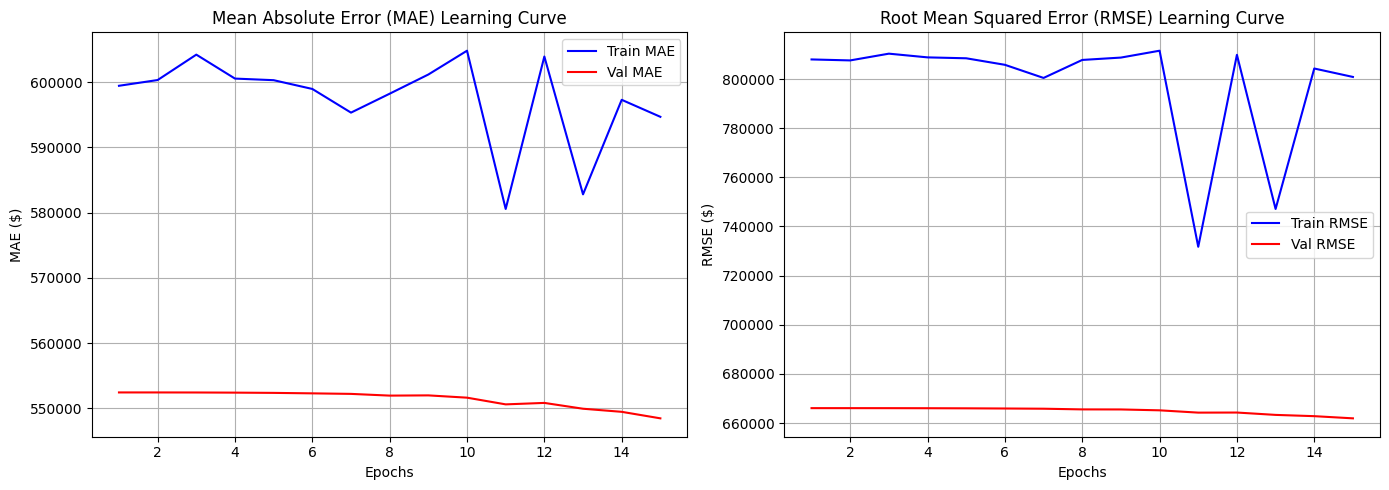

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE Plot
ax1.plot(range(1, EPOCHS + 1), train_maes, label="Train MAE", color="blue")
ax1.plot(range(1, EPOCHS + 1), val_maes, label="Val MAE", color="red")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MAE ($)")
ax1.set_title("Mean Absolute Error (MAE) Learning Curve")
ax1.legend()
ax1.grid(True)

# RMSE Plot
ax2.plot(range(1, EPOCHS + 1), train_rmses, label="Train RMSE", color="blue")
ax2.plot(range(1, EPOCHS + 1), val_rmses, label="Val RMSE", color="red")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("RMSE ($)")
ax2.set_title("Root Mean Squared Error (RMSE) Learning Curve")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Step 10: Validation Test (Simulate Web Serving API)

We load the best model weights back, prepare a mock image and structured dataset, and predict value directly on CPU to verify flawless web app integration.

In [18]:
loaded_model = MultimodalHousingPriceModel(tabular_input_dim=tabular_dim)
loaded_model.load_state_dict(torch.load("multimodal_house_model.pth", map_location="cpu"))
loaded_model.eval()

# Create dummy image (3 channels, 224x224 size) and tabular inputs matching batch dimension
mock_image = torch.randn(1, 3, 224, 224)
mock_tabular = torch.randn(1, tabular_dim)

with torch.no_grad():
    predicted_price = loaded_model(mock_image, mock_tabular).item()
    
print(f"\nMock Multimodal Inference Successful!")
print(f"Estimated Housing Price: ${predicted_price:,.2f}")


Mock Multimodal Inference Successful!
Estimated Housing Price: $29,829.18
